# Assignment 4
## Part 2: Fundamental Matrix Estimation, Camera Calibration, Triangulation
Mohammad Rashiqul Alam  
malam25@illinois.edu  

In [19]:
# Imports
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

### Fundamental Matrix Estimation


#### Normalized 8-Point Algorithm for Fundamental Matrix Estimation

The `fit_fundamental_normalized` function implements the normalized 8-point algorithm to estimate the fundamental matrix $F$ from a set of ground truth point correspondences between two images. This method is required by the assignment to compare with the unnormalized version.

**Why normalization?**  
Normalization improves numerical stability and accuracy by translating and scaling the input points so that their centroid is at the origin and their average distance from the origin is $\sqrt{2}$. This reduces the effect of coordinate scale and location on the solution.

**Steps performed:**
1. **Normalize** the coordinates of the matching points in both images.
2. **Construct** the matrix $A$ from the normalized correspondences, encoding the epipolar constraint for each match.
3. **Solve** the homogeneous linear system $Af=0$ using SVD to obtain the fundamental matrix $F$.
4. **Enforce** the rank-2 constraint on $F$ by setting its smallest singular value to zero.
5. **Denormalize** $F$ to return to the original coordinate system.

This function is used to fit $F$ for both the lab and library image pairs, as required by the assignment, and is compared to the unnormalized algorithm. The quality of the estimated $F$ is evaluated by the mean squared distance (residual) between the points and their corresponding epipolar lines in both images.

In [20]:
def fit_fundamental_normalized(matches):
    """
    Normalized 8-point algorithm.
    Input: matches shape (N,4): [x1,y1,x2,y2]
    Output: F (3x3) with rank=2
    """
    import numpy as np

    # Helper: Normalize points so that centroid is at origin and mean distance is sqrt(2)
    def _normalize_points(pts):
        m = pts.mean(axis=0)  # centroid
        d = np.sqrt(((pts - m)**2).sum(axis=1)).mean()  # mean distance to centroid
        s = np.sqrt(2) / d if d > 0 else 1.0  # scaling factor
        # Similarity transform matrix
        T = np.array([[s, 0, -s*m[0]],
                      [0, s, -s*m[1]],
                      [0, 0,      1  ]], dtype=float)
        pts_h = np.c_[pts, np.ones(len(pts))]  # homogeneous coordinates
        n = (T @ pts_h.T).T  # apply normalization
        return n[:, :2], T

    x1 = matches[:, 0:2].astype(float)  # points in image 1
    x2 = matches[:, 2:4].astype(float)  # points in image 2

    # Normalize both sets of points
    x1n, T1 = _normalize_points(x1)
    x2n, T2 = _normalize_points(x2)

    # Build matrix A for the linear system Af=0
    N = matches.shape[0]
    A = np.zeros((N, 9), dtype=float)
    for i in range(N):
        u, v = x1n[i]
        up, vp = x2n[i]
        # Each row encodes the epipolar constraint for a correspondence
        A[i] = [u*up, v*up, up, u*vp, v*vp, vp, u, v, 1.0]

    # Solve Af=0 using SVD; F is the last column of V (reshaped to 3x3)
    _, _, Vt = np.linalg.svd(A)
    F = Vt[-1].reshape(3, 3)

    # Enforce rank-2 constraint on F by zeroing the smallest singular value
    Uf, Sf, Vtf = np.linalg.svd(F)
    Sf[2] = 0.0
    F_rank2 = Uf @ np.diag(Sf) @ Vtf

    # Denormalize: transform F back to original coordinates
    F = T2.T @ F_rank2 @ T1

    # Scale F so that F[2,2] = 1 for consistency
    if abs(F[2, 2]) > 1e-8:
        F = F / F[2, 2]
    return F

#### Unnormalized 8-Point Algorithm for Fundamental Matrix Estimation

The `fit_fundamental_unnormalized` function implements the classic 8-point algorithm to estimate the fundamental matrix $F$ directly from the given point correspondences, **without** any normalization of the input coordinates.

**Why use the unnormalized version?**  
This method is included for comparison, as required by the assignment. While it is straightforward, it is sensitive to the scale and distribution of the input points, which can lead to poor numerical stability and less accurate results compared to the normalized version.

**Steps performed:**
1. **Directly use** the original coordinates of the matching points in both images.
2. **Construct** the matrix $A$ from the correspondences, encoding the epipolar constraint for each match.
3. **Solve** the homogeneous linear system $Af=0$ using SVD to obtain the fundamental matrix $F$.
4. **Enforce** the rank-2 constraint on $F$ by setting its smallest singular value to zero.
5. **Optionally normalize** $F$ so that $F_{2,2} = 1$ for consistency.

This function allows you to observe the effect of normalization by comparing its results (residuals and visualizations) to those from the normalized algorithm, as required by the assignment.

In [21]:
def fit_fundamental_unnormalized(matches):
    """Unnormalized 8-point algorithm."""
    import numpy as np
    x1 = matches[:, :2].astype(float)   # Points from image 1
    x2 = matches[:, 2:].astype(float)   # Corresponding points from image 2
    N = matches.shape[0]
    A = np.zeros((N, 9))
    for i in range(N):
        u, v = x1[i]        # (u, v) in image 1
        up, vp = x2[i]      # (up, vp) in image 2
        # Each row encodes the epipolar constraint for a correspondence
        A[i] = [u*up, v*up, up, u*vp, v*vp, vp, u, v, 1]
    # Solve Af=0 using SVD; F is the last column of V (reshaped to 3x3)
    _, _, Vt = np.linalg.svd(A)
    F = Vt[-1].reshape(3, 3)
    # Enforce rank-2 constraint on F by zeroing the smallest singular value
    Uf, Sf, Vtf = np.linalg.svd(F)
    Sf[2] = 0
    F = Uf @ np.diag(Sf) @ Vtf
    # Normalize so that F[2,2] = 1 (optional, for consistency)
    return F / F[2, 2]

#### Wrapper for Fundamental Matrix Estimation: `fit_fundamental`

The `fit_fundamental` function is a simple wrapper that runs both the normalized and unnormalized 8-point algorithms for fundamental matrix estimation. It calls `fit_fundamental_normalized` and `fit_fundamental_unnormalized` on the same set of point correspondences and returns both results.

**Purpose in the assignment:**  
This function allows you to easily compare the performance and results of the normalized and unnormalized algorithms, as required by the assignment. By using this wrapper, you can fit both versions of the fundamental matrix for each image pair and directly compare their residuals and visualizations.

**Usage:**  
- Call `fit_fundamental(matches)` to obtain both $F_{normalized}$ and $F_{unnormalized}$ for a given set of matches.
- Use the returned matrices to compute and visualize epipolar lines, and to report residuals for both methods.

In [22]:
def fit_fundamental(matches):
    """
    Wrapper function to fit the fundamental matrix using the normalized and unnormalized 8-point algorithm 
    """
    # Execute normalized 8-point algorithm
    F_normalized = fit_fundamental_normalized(matches)
    # Execute unnormalized 8-point algorithm
    F_unnormalized = fit_fundamental_unnormalized(matches)
    return F_normalized, F_unnormalized

#### Plotting Functions

- **show_matches**:  
  Displays two images side-by-side with the matching points and lines connecting each correspondence. This visualization helps verify the quality and distribution of the provided matches.

- **plot_epipolar_lines**:  
  Plots the epipolar lines in the second image corresponding to points in the first image, using a given fundamental matrix. It also shows the closest points on the epipolar lines to the actual matches, providing visual feedback on the accuracy of the estimated fundamental matrix.

In [23]:
def plot_epipolar_lines(F, I2, matches, title):
    """
    Plot epipolar lines in the second image for a set of point correspondences and a fundamental matrix.

    Args:
        F (np.ndarray): The 3x3 fundamental matrix.
        I2 (PIL.Image or np.ndarray): The second image (where epipolar lines are drawn).
        matches (np.ndarray): Array of shape (N, 4), each row is [x1, y1, x2, y2] for a match.
        title (str): Title for the plot.

    This function computes the epipolar lines in the second image corresponding to points in the first image,
    finds the closest points on those lines to the actual matches, and visualizes both the matches and the lines.
    """
    N = len(matches)
    # Convert points from image 1 to homogeneous coordinates
    M = np.c_[matches[:,0:2], np.ones((N,1))].T
    # Compute epipolar lines in image 2 for points from image 1
    L1 = (F @ M).T  # Each row is the line coefficients [a, b, c] for ax + by + c = 0
    # Normalize lines for distance computation
    l = np.sqrt(L1[:,0]**2 + L1[:,1]**2)
    L = L1 / l[:, np.newaxis]
    # Compute distance from each match in image 2 to its epipolar line
    pt_line_dist = np.sum(L * np.c_[matches[:,2:4], np.ones((N,1))], axis=1)
    # Find closest points on the epipolar lines to the actual matches
    closest_pt = matches[:,2:4] - L[:,0:2] * pt_line_dist[:, np.newaxis]
    # Compute endpoints for line segments (for visualization)
    pt1 = closest_pt - np.c_[L[:,1], -L[:,0]] * 10  # Offset from closest point
    pt2 = closest_pt + np.c_[L[:,1], -L[:,0]] * 10

    # Plot the image, matches, and epipolar lines
    fig, ax = plt.subplots()
    ax.set_aspect('equal')
    ax.imshow(np.array(I2).astype(float))
    ax.plot(matches[:,2], matches[:,3], '+r', label='Matched Points')
    ax.plot([matches[:,2], closest_pt[:,0]], [matches[:,3], closest_pt[:,1]], 'r', label='Perpendiculars')
    ax.plot([pt1[:,0], pt2[:,0]], [pt1[:,1], pt2[:,1]], 'g', label='Epipolar Lines')
    ax.set_title(title)
    plt.show()

In [24]:
def show_matches(I1, I2, matches, title="Matches"):
    """
    Display two images side-by-side with matching points and lines drawn between them.

    Args:
        I1 (PIL.Image or np.ndarray): The first image.
        I2 (PIL.Image or np.ndarray): The second image.
        matches (np.ndarray): Array of shape (N, 4), each row is [x1, y1, x2, y2] for a match.
        title (str): Title for the plot.

    This function visualizes the correspondences between two images by plotting the matched points
    and drawing lines connecting each pair.
    """
    # Create a blank image to hold both images side by side
    I3 = np.zeros((I1.size[1], I1.size[0]*2, 3))
    I3[:,:I1.size[0],:] = I1  # Place first image on the left
    I3[:,I1.size[0]:,:] = I2  # Place second image on the right

    # Set up the plot
    fig, ax = plt.subplots()
    ax.set_aspect('equal')
    ax.imshow(np.array(I3).astype(float))

    # Plot matched points in the first image (left)
    ax.plot(matches[:,0], matches[:,1], '+r')
    # Plot matched points in the second image (right, offset by image width)
    ax.plot(matches[:,2]+I1.size[0], matches[:,3], '+r')
    # Draw lines connecting each pair of matched points
    ax.plot([matches[:,0], matches[:,2]+I1.size[0]], [matches[:,1], matches[:,3]], 'r')
    ax.set_title(title)
    plt.show()

#### Fundamental Matrix Analysis Function

The `analyze_fundamental_matrix` function streamlines the process of evaluating and visualizing fundamental matrix estimation for any image pair and set of ground truth matches. It performs the following steps:

1. **show_matches**: Displays the two images side-by-side with the matching points and lines connecting each correspondence.
2. **fit_fundamental**: Estimates both the normalized and unnormalized fundamental matrices using the provided matches.
3. **compute_epipolar_residual**: Calculates and reports the mean squared distance (residual) between points and their corresponding epipolar lines for each estimated fundamental matrix.
4. **plot_epipolar_lines**: Visualizes the epipolar lines in the second image for both the normalized and unnormalized fundamental matrices.

This modular approach makes it easy to compare results for different datasets, such as the lab and library pairs, in a clear and consistent way.

In [25]:
def compute_epipolar_residual(matches, F):
    """
    Compute the mean squared distance (residual) between points in image 2 and their corresponding epipolar lines
    (computed from points in image 1 and the fundamental matrix F).

    Args:
        matches (np.ndarray): Array of shape (N, 4), each row is [x1, y1, x2, y2].
        F (np.ndarray): The 3x3 fundamental matrix.

    Returns:
        float: Mean squared distance (residual) in pixels.
    """
    N = matches.shape[0]
    # Points in image 1 (homogeneous)
    pts1 = np.c_[matches[:, 0:2], np.ones(N)]
    # Points in image 2 (homogeneous)
    pts2 = np.c_[matches[:, 2:4], np.ones(N)]

    # Epipolar lines in image 2 for points from image 1: l2 = F @ pts1.T
    l2 = (F @ pts1.T).T  # shape (N, 3)
    # Normalize lines for distance computation
    l2 = l2 / np.sqrt(l2[:, 0]**2 + l2[:, 1]**2)[:, np.newaxis]

    # Distance from each point in image 2 to its epipolar line in image 2
    dists = np.abs(np.sum(l2 * pts2, axis=1))

    # Return mean squared distance
    return np.mean(dists ** 2)

In [26]:
def analyze_fundamental_matrix(img1_path, img2_path, matches_path, label):
    """
    Load two images and their matches, fit both normalized and unnormalized fundamental matrices,
    and visualize the matches and epipolar lines for both algorithms.

    Args:
        img1_path (str): Path to the first image.
        img2_path (str): Path to the second image.
        matches_path (str): Path to the file containing point correspondences.
        label (str): Label for plots (e.g., "Library" or "Lab").

    This function helps compare the normalized and unnormalized 8-point algorithms
    by visualizing their results for a given image pair and set of matches.
    """
    # Load images and matches from files
    I1 = Image.open(img1_path)
    I2 = Image.open(img2_path)
    matches = np.loadtxt(matches_path)
    N = len(matches)

    # Visualize the matches between the two images
    show_matches(I1, I2, matches, title=f"{label} Matches")

    # Fit both normalized and unnormalized fundamental matrices
    F_norm, F_unnorm = fit_fundamental(matches)

    # Compute and report residuals for both algorithms
    res_norm = compute_epipolar_residual(matches, F_norm)
    res_unnorm = compute_epipolar_residual(matches, F_unnorm)
    print(f"{label} - Normalized F residual: {res_norm:.4f}")
    print(f"{label} - Unnormalized F residual: {res_unnorm:.4f}")

    # Visualize epipolar lines for the normalized fundamental matrix
    plot_epipolar_lines(F_norm, I2, matches, f"Epipolar Lines (Normalized F) - {label}")
    # Visualize epipolar lines for the unnormalized fundamental matrix
    plot_epipolar_lines(F_unnorm, I2, matches, f"Epipolar Lines (Unnormalized F) - {label}")

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


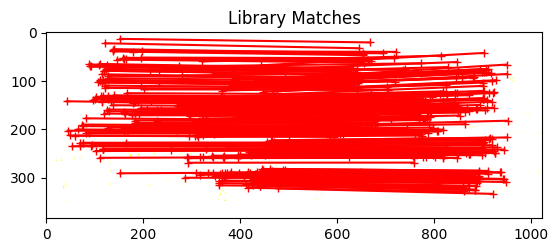

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


Library - Normalized F residual: 0.0603
Library - Unnormalized F residual: 0.1792


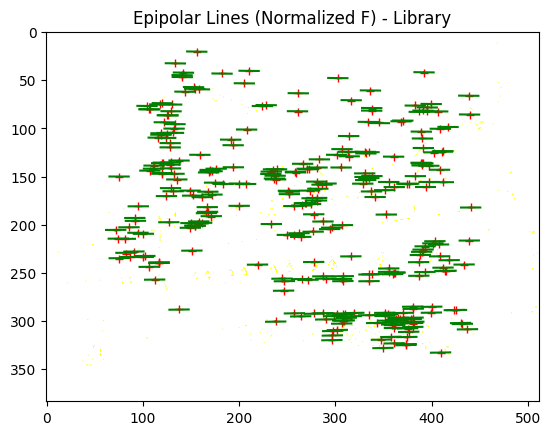

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


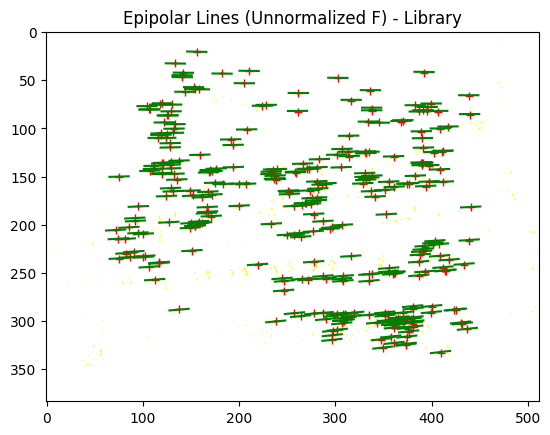

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


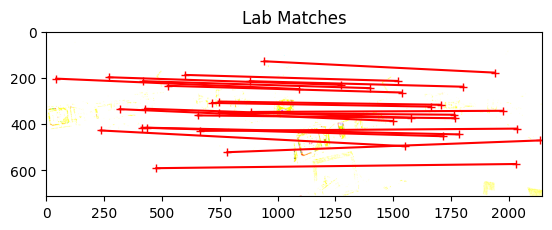

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


Lab - Normalized F residual: 0.5483
Lab - Unnormalized F residual: 6.5671


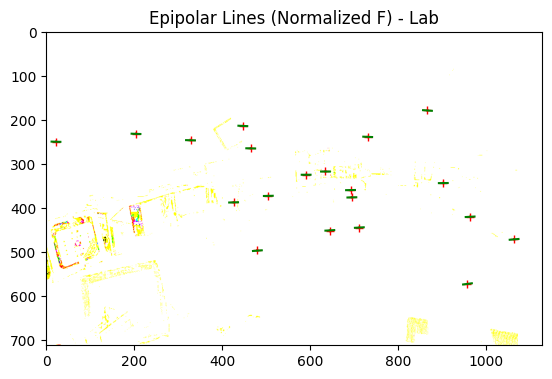

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


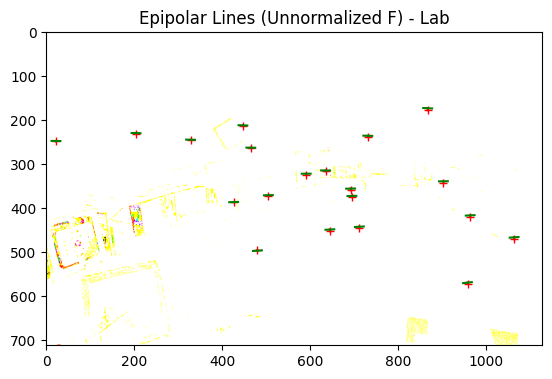

In [27]:
# Run for library pair
analyze_fundamental_matrix(
    'MP4_part2_data/library1.jpg',
    'MP4_part2_data/library2.jpg',
    'MP4_part2_data/library_matches.txt',
    label="Library"
)

# Run for lab pair
analyze_fundamental_matrix(
    'MP4_part2_data/lab1.jpg',
    'MP4_part2_data/lab2.jpg',
    'MP4_part2_data/lab_matches.txt',
    label="Lab"
)

### Camera Calibration

For the **lab pair**, we compute the camera projection matrix using the Direct Linear Transform (DLT) algorithm, which takes as input the 2D image points and their corresponding 3D world coordinates from `lab_3d.txt`. After estimating the projection matrix, we use the provided `evaluate_points` function to project the 3D points back into the image and compute the residual error. A low residual (empirically < 20) indicates a good calibration.

For the **library pair**, ground truth 3D points are not available. Instead, the camera projection matrices are provided in `library1_camera.txt` and `library2_camera.txt` and can be loaded directly for further processing.

#### Camera Projection Matrix Estimation: `compute_projection_matrix`

The `compute_projection_matrix` function implements the Direct Linear Transform (DLT) algorithm to estimate the $3 \times 4$ camera projection matrix $M$ from a set of 3D world points and their corresponding 2D image points. This matrix describes how 3D points in the world are mapped to 2D points in the image.

**How it works:**
- For each 3D-2D correspondence, the function constructs two linear equations relating the unknown entries of $M$ to the observed coordinates.
- All equations are stacked into a matrix $A$, and the solution is found by minimizing $|A m|$ subject to $|m|=1$ using Singular Value Decomposition (SVD).
- The resulting vector is reshaped into the $3 \times 4$ projection matrix.

This method is widely used for camera calibration when both 3D and 2D correspondences are available.

In [28]:
def compute_projection_matrix(points_2d, points_3d):
    """
    Compute the camera projection matrix M using the DLT algorithm.

    Args:
        points_2d (np.ndarray): (N, 2) array of 2D image points.
        points_3d (np.ndarray): (N, 3) array of corresponding 3D world points.

    Returns:
        M (np.ndarray): (3, 4) camera projection matrix.
    """
    N = points_2d.shape[0]
    A = []
    for i in range(N):
        X, Y, Z = points_3d[i]
        u, v = points_2d[i]
        # Each correspondence gives two equations:
        # [X Y Z 1 0 0 0 0 -uX -uY -uZ -u] for u
        # [0 0 0 0 X Y Z 1 -vX -vY -vZ -v] for v
        A.append([X, Y, Z, 1, 0, 0, 0, 0, -u*X, -u*Y, -u*Z, -u])
        A.append([0, 0, 0, 0, X, Y, Z, 1, -v*X, -v*Y, -v*Z, -v])
    A = np.array(A)
    # Solve A @ m = 0 using SVD; m is the last row of V^T
    _, _, Vt = np.linalg.svd(A)
    m = Vt[-1]
    # Reshape m into the 3x4 projection matrix
    M = m.reshape(3, 4)
    # Normalize M to stabilize scale
    M = M / np.linalg.norm(M[-1, :3])
    return M

### Loading Data for Camera Calibration

To perform camera calibration, we first need to load the relevant data files for both the lab and library image pairs:

- **Lab Pair:**  
  - We use the 2D image matches from `lab_matches.txt` and the corresponding 3D world coordinates from `lab_3d.txt`.  
  - These files provide the necessary correspondences to compute the camera projection matrix using the DLT algorithm.

- **Library Pair:**  
  - There are no ground truth 3D points available for the library images.  
  - Instead, the camera projection matrices are already provided in `library1_camera.txt` and `library2_camera.txt`, and can be loaded directly for further processing.

In [29]:
def load_camera_matrix(filename):
    """
    Wrapper to load a 3x4 camera matrix from a text file.
    """
    return np.loadtxt(filename)

In [30]:
# For the lab pair
points_2d_lab = np.loadtxt('MP4_part2_data/lab_matches.txt')[:, :2]  # shape (N,2)
points_3d_lab = np.loadtxt('MP4_part2_data/lab_3d.txt')              # shape (N,3)
# Calculate the projection matrix
M_lab = compute_projection_matrix(points_2d_lab, points_3d_lab)

# For the library pair
M_lib1 = load_camera_matrix('MP4_part2_data/library1_camera.txt')
M_lib2 = load_camera_matrix('MP4_part2_data/library2_camera.txt')

In [31]:
def evaluate_points(M, points_2d, points_3d):
    """
    Visualize the actual 2D points and the projected 2D points calculated from
    the projection matrix
    You do not need to modify anything in this function, although you can if you
    want to
    :param M: projection matrix 3 x 4
    :param points_2d: 2D points N x 2
    :param points_3d: 3D points N x 3
    :return:
    """
    N = len(points_3d)
    points_3d = np.hstack((points_3d, np.ones((N, 1))))
    points_3d_proj = np.dot(M, points_3d.T).T
    u = points_3d_proj[:, 0] / points_3d_proj[:, 2]
    v = points_3d_proj[:, 1] / points_3d_proj[:, 2]
    residual = np.sum(np.hypot(u-points_2d[:, 0], v-points_2d[:, 1]))
    points_3d_proj = np.hstack((u[:, np.newaxis], v[:, np.newaxis]))
    return points_3d_proj, residual


In [32]:
# Evaluate for lab pair
proj_2d, residual = evaluate_points(M_lab, points_2d_lab, points_3d_lab)
print(f"Lab pair projection matrix residual: {residual:.4f}")

# Check the mean squared distance between the projected 2D points and the actual 2D points
msd = np.mean(np.sum((proj_2d - points_2d_lab)**2, axis=1))
print(f"Lab pair mean squared distance: {msd:.4f}")

Lab pair projection matrix residual: 13.5458
Lab pair mean squared distance: 0.7862


### Camera Center Calculation

After calibrating the camera and obtaining the projection matrix, the next step is to compute the camera center in 3D space. The camera center represents the position of the camera in the world coordinate system and can be found as the null space of the $3 \times 4$ projection matrix $M$. This is useful for visualizing the camera setup and for further 3D reconstruction tasks.

In [33]:
def camera_center(M):
    """
    Compute the camera center C as the null space of the camera projection matrix M.
    The camera center satisfies M @ [C; 1] = 0.

    Args:
        M (np.ndarray): (3, 4) camera projection matrix.

    Returns:
        C (np.ndarray): (3,) camera center in world coordinates.
    """
    import numpy as np
    # Perform SVD on M
    U, S, Vt = np.linalg.svd(M)
    # The last row of Vt (or last column of V) is the null space
    C_h = Vt[-1]
    # Convert from homogeneous to Euclidean coordinates
    C = C_h[:3] / C_h[3]
    return C

### Triangulation of 3D Points

With the camera projection matrices for both views, we can now triangulate the 3D positions of each pair of matching 2D points. This is done using a linear least squares method (DLT), which reconstructs the 3D point that best explains the observed projections in both images.

- **Lab Pair:**  
  Triangulated 3D points should closely match the ground truth 3D points provided in `lab_3d.txt`. This serves as a sanity check for the accuracy of the triangulation.

- **Library Pair:**  
  Since ground truth 3D points are not available, we only visualize the reconstructed 3D points and camera centers.

> **Note:** The camera centers are not used in the triangulation computation itself—they are only included in the 3D visualization for reference.

After triangulation, we will:
- Visualize the two camera centers and the reconstructed 3D points in a 3D plot for each pair.
- Report the residuals between the observed 2D points and the projections of the triangulated 3D points in both images.

In [34]:
def triangulate_points(M1, pts1, M2, pts2):
    """
    Linear triangulation (DLT) per the assignment hints:
    build the 4x4 system using u*P3 - P1 and v*P3 - P2, solve with SVD.
    pts1, pts2: (N,2) image coords; M1, M2: 3x4 projection matrices.
    Returns: (N,3) Euclidean 3D points.
    """
    import numpy as np

    P1, P2 = M1, M2
    N = pts1.shape[0]
    X = np.zeros((N, 3), dtype=float)

    for i in range(N):
        # Get corresponding points in both images
        u1, v1 = float(pts1[i,0]), float(pts1[i,1])
        u2, v2 = float(pts2[i,0]), float(pts2[i,1])

        # Build the 4x4 linear system for this correspondence
        # Each row encodes the projection equation for one coordinate in one image
        # u*P3 - P1 and v*P3 - P2 for both cameras
        A = np.vstack([
            u1*P1[2,:] - P1[0,:],  # from image 1, x
            v1*P1[2,:] - P1[1,:],  # from image 1, y
            u2*P2[2,:] - P2[0,:],  # from image 2, x
            v2*P2[2,:] - P2[1,:],  # from image 2, y
        ])

        # Optional: row-normalize to improve conditioning (doesn't change solution direction)
        A = A / np.linalg.norm(A, axis=1, keepdims=True)

        # Solve AX=0 using SVD; solution is last row of Vt (homogeneous 3D point)
        _, _, Vt = np.linalg.svd(A)
        Xh = Vt[-1]                 # homogeneous 3D
        X[i] = Xh[:3] / Xh[3]       # convert to Euclidean coordinates

    return X

### 3D Visualization and Comparison of Triangulated Points

The function `plot_3d_points_and_cameras` is used to visualize the reconstructed 3D points and the positions of the two camera centers for each image pair. This 3D plot provides an intuitive way to assess the spatial distribution of the triangulated points relative to the cameras.

- **Lab Pair:**  
  The triangulated 3D points are expected to closely match the ground truth 3D points from `lab_3d.txt`. By visualizing these points along with the camera centers, we can qualitatively verify the accuracy of the reconstruction.

- **Library Pair:**  
  Since ground truth 3D points are not available, the visualization helps us understand the geometry of the reconstructed scene and the relative positions of the cameras.

The subsequent code cells use this function to display the 3D points and camera centers for both the lab and library pairs, enabling a direct visual comparison between the two cases.

In [35]:
def plot_3d_points_and_cameras(points_3d, C1, C2, title="3D Points and Camera Centers"):
    """
    Visualize 3D points and two camera centers in a 3D plot.
    """
    from mpl_toolkits.mplot3d import Axes3D
    import matplotlib.pyplot as plt
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    # Plot the triangulated 3D points as blue dots
    ax.scatter(points_3d[:,0], points_3d[:,1], points_3d[:,2], c='b', label='Triangulated Points')
    # Plot the first camera center as a red triangle
    ax.scatter(C1[0], C1[1], C1[2], c='r', marker='^', s=100, label='Camera 1 Center')
    # Plot the second camera center as a green triangle
    ax.scatter(C2[0], C2[1], C2[2], c='g', marker='^', s=100, label='Camera 2 Center')
    # Add legend and axis labels
    ax.legend()
    ax.set_title(title)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    plt.show()

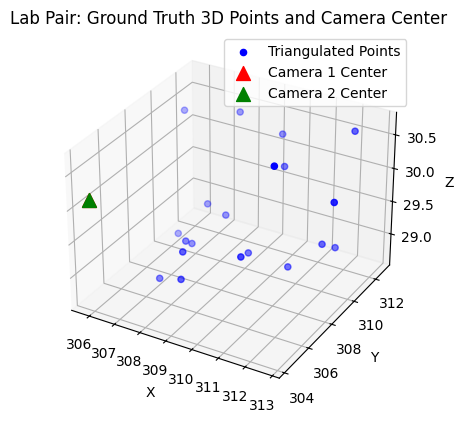

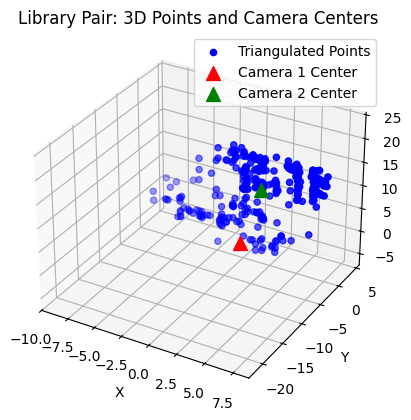

In [36]:
# For the lab pair: DO NOT triangulate using the same camera matrix for both views.
# Instead, just visualize the provided 3D points and the single camera center.

# Load ground truth 3D points for lab pair
points_3d_lab = np.loadtxt('MP4_part2_data/lab_3d.txt')
C_lab = camera_center(M_lab)

# Visualize the ground truth 3D points and the camera center for the lab pair
plot_3d_points_and_cameras(points_3d_lab, C_lab, C_lab, title="Lab Pair: Ground Truth 3D Points and Camera Center")

# For the library pair: Triangulation is valid since you have two different camera matrices
matches_lib = np.loadtxt('MP4_part2_data/library_matches.txt')  # Load 2D matches for library images
pts1_lib = matches_lib[:, :2]  # 2D points in image 1
pts2_lib = matches_lib[:, 2:4]  # 2D points in image 2
triangulated_lib = triangulate_points(M_lib1, pts1_lib, M_lib2, pts2_lib)  # Triangulate 3D points using both views

# Compute camera centers for library pair
C_lib1 = camera_center(M_lib1)
C_lib2 = camera_center(M_lib2)

# Plot for library pair: show triangulated points and camera centers
plot_3d_points_and_cameras(triangulated_lib, C_lib1, C_lib2, title="Library Pair: 3D Points and Camera Centers")